In [37]:
# this is essentially going to be the code jill wrote in time_cutoffs.ipynb (jill branch)
# but i rewrite here to both learn how it works and to make sure the object types between this and PSDProd will play nice

In [38]:
# standard imports
import pandas as pd
import numpy as np
from scipy.signal import welch
import matplotlib.pyplot as plt
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'DejaVu Sans'
# plt.rcParams['figure.figsize'] = (3,2)
# plt.rcParams["figure.dpi"] = 300

In [39]:
# import CSVs and such
voltagedata = pd.read_csv('./output/stationTest.CSV') # it seems like this is the old 10 Hz sampling :(
voltagedata['voltage'] = voltagedata['sensor'] * (5 / 16383)
sampFreq = 10

# import clicker data, unfortunately this does not exists on the repo :(
# events every 200 seconds, should give enough room for both event and background
clickerdata = pd.read_csv('./output/clickerFAKE.csv')

# now want to control the windowing params around events
window_half_width = 20 # enforce that this is seconds somehow
use_exact_match = False
max_time_diff = 0.1

voltagedata['seconds'] = pd.to_numeric(voltagedata['seconds'], errors='coerce')
clickerdata['seconds'] = pd.to_numeric(clickerdata['seconds'], errors='coerce')

voltDrop = voltagedata.dropna(subset=['seconds']).reset_index(drop=True)
clickDrop = clickerdata.dropna(subset=['seconds']).reset_index(drop=True)

In [40]:
voltagedata

,timecode,seconds,lat,lat_dir,lon,lon_dir,sensor,voltage
0,260407_224230_000,81750.000,4200.0562,N,8739.6826,W,72,0.021974
1,260407_224230_426,81750.430,4200.0562,N,8739.6826,W,84,0.025636
2,260407_224230_525,81750.523,4200.0562,N,8739.6826,W,92,0.028078
3,260407_224230_625,81750.625,4200.0562,N,8739.6826,W,97,0.029604
4,260407_224230_725,81750.727,4200.0562,N,8739.6826,W,103,0.031435
...,...,...,...,...,...,...,...,...
10593,260407_230010_000,82810.000,4200.0562,N,8739.6748,W,65,0.019838
10594,260407_230010_100,82810.102,4200.0562,N,8739.6748,W,58,0.017701
10595,260407_230010_200,82810.203,4200.0562,N,8739.6748,W,83,0.025331
10596,260407_230010_300,82810.297,4200.0562,N,8739.6748,W,110,0.033571


In [41]:
bigVoltArr = voltagedata['voltage'].to_numpy()

In [42]:
# initial seconds may not line up, want to shift
# im not quite sure why we want both to start at 0 tho? then it feels like we would mismatch
# if the first event is when the seismometer starts recording, then we should drop the first entry in clickAdjSecs
# if the clicks are UTC seconds, adjust as below
# if not, figure it out bruh
t0Volt = voltDrop['seconds'].iloc[0]
t0Click = clickDrop['seconds'].iloc[0]

voltDrop['adjSecs'] = voltDrop['seconds'] - t0Volt
clickDrop['adjSecs'] = clickDrop['seconds'] - t0Click

voltSecs = voltDrop['seconds'].to_numpy()
clickSecs = clickDrop['seconds'].to_numpy()
voltAdjSecs = voltDrop['adjSecs'].to_numpy()
clickAdjSecs = clickDrop['adjSecs'].to_numpy()

print(f'voltage csv first time was {t0Volt}, now is {voltAdjSecs[0]}')
print(f'clicker csv first time was {t0Click}, now is {clickAdjSecs[0]}')

# kill entry in clickAdjSecs for recording start
clickAdjSecs = clickAdjSecs[1:]

voltage csv first time was 81750.0, now is 0.0
clicker csv first time was 0, now is 0


In [43]:
# jill wrote a complicated matching thing, which looks nice but i imagine for our purposes some type of searchsorted would work fineish
eventIdxArr = []
for event in clickAdjSecs:
    eventIdx = np.searchsorted(voltAdjSecs,event)
    eventIdxArr.append(eventIdx)
eventIdxArr = np.array(eventIdxArr)

eventIdxArr

array([ 994, 2994, 4994, 6993, 8992])

In [44]:
# comment for reference in 5 minutes...
# add half window width to each event index
# then, make array of tuples for these guys
# inside the window indexes are events, then make another array with indexes between the windows as bckgd
# then we can slice and dice how we please

In [45]:
# important that this allows ample time after the last event to not have any errors
halfWIndex = window_half_width * sampFreq

In [46]:
# thank you evil death robot for writing this for me
noiseWIndex = []
eventWIndex = []

n = len(voltAdjSecs)  # total valid sample indices: 0 .. n-1

# 1) Build raw event windows [low, high] around each event index
for idx in eventIdxArr:
    low = max(0, int(idx - halfWIndex))
    high = min(n - 1, int(idx + halfWIndex))
    eventWIndex.append([low, high])

# 2) Sort + merge overlapping/touching event windows
eventWIndex.sort(key=lambda w: w[0])
merged = []
for low, high in eventWIndex:
    if not merged or low > merged[-1][1] + 1:
        merged.append([low, high])
    else:
        merged[-1][1] = max(merged[-1][1], high)

eventWIndex = merged

# 3) Fill gaps as noise windows (complement of event windows)
cursor = 0
for low, high in eventWIndex:
    if cursor < low:
        noiseWIndex.append([cursor, low - 1])
    cursor = high + 1

if cursor <= n - 1:
    noiseWIndex.append([cursor, n - 1])

print("eventWIndex:", eventWIndex)
print("noiseWIndex:", noiseWIndex)

eventWIndex: [[794, 1194], [2794, 3194], [4794, 5194], [6793, 7193], [8792, 9192]]
noiseWIndex: [[0, 793], [1195, 2793], [3195, 4793], [5195, 6792], [7194, 8791], [9193, 10597]]


In [47]:
noiseArrs = []
for low,high in noiseWIndex:
    noiseArrs.append(bigVoltArr[low:high])

eventArrs = []
for low,high in eventWIndex:
    eventArrs.append(bigVoltArr[low:high])

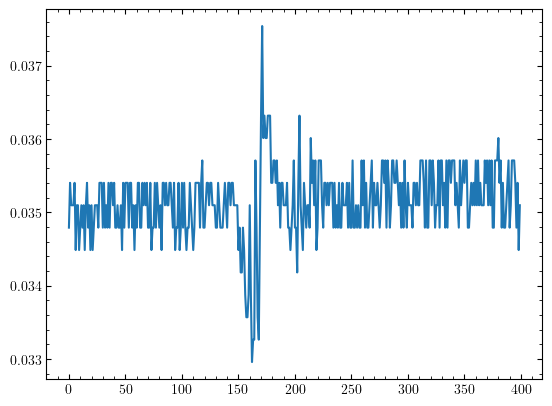

In [49]:
plt.plot(eventArrs[0])